# Exercice 1.3 bis : Analyse multivariée — corrélation et structure (localisation)

Variante de E3 : les prédicteurs sont surtout **catégoriels**. On les encode (one-hot) pour construire des corrélations avec `SalePrice`, analyser la multicolinéarité sur les indicatrices, et explorer des corrélations partielles.


## Section 1: Imports et préparation


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

df = pd.read_csv("AmesHousing.csv")
df.columns = df.columns.str.replace(" ", "")
COLS_LOC = ["Neighborhood", "MSZoning", "Condition1", "Condition2", "SalePrice"]
df_loc = df[COLS_LOC].dropna().copy()

X_cat = df_loc[["Neighborhood", "MSZoning", "Condition1", "Condition2"]]
y = df_loc["SalePrice"]

ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_dum = pd.DataFrame(
    ohe.fit_transform(X_cat),
    columns=ohe.get_feature_names_out(X_cat.columns),
    index=df_loc.index,
)
df_num = pd.concat([X_dum, y.rename("SalePrice")], axis=1)
print(df_num.shape)
print(df_num.iloc[:, :8].head())
# Les 8 premières colonnes = début des Neighborhood_* (ordre alphabétique) ; pas forcément le quartier de la ligne.
s0 = df_num.iloc[0].drop("SalePrice", errors="ignore")
print("Indicatrices à 1 pour la ligne 0 :")
print(s0[s0 == 1])


(2197, 53)
   Neighborhood_Blmngtn  Neighborhood_Blueste  Neighborhood_BrDale  \
0                   0.0                   0.0                  0.0   
1                   0.0                   0.0                  0.0   
2                   0.0                   0.0                  0.0   
3                   0.0                   0.0                  0.0   
4                   0.0                   0.0                  0.0   

   Neighborhood_BrkSide  Neighborhood_ClearCr  Neighborhood_CollgCr  \
0                   0.0                   0.0                   0.0   
1                   0.0                   0.0                   0.0   
2                   0.0                   0.0                   0.0   
3                   0.0                   0.0                   0.0   
4                   0.0                   0.0                   0.0   

   Neighborhood_Crawfor  Neighborhood_Edwards  
0                   0.0                   0.0  
1                   0.0                   0.0

## Section 2: Matrice de corrélation (Pearson) — `SalePrice` vs indicatrices

**À faire :** heatmap des corrélations entre `SalePrice` et les colonnes dummy (afficher un sous-ensemble : par ex. les 30 corrélations les plus fortes en valeur absolue).


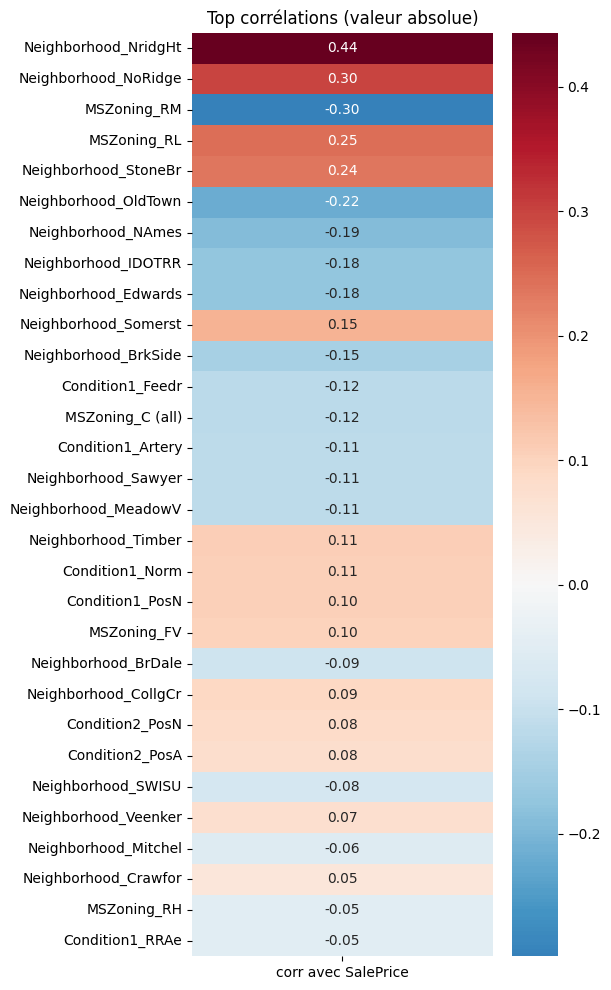

In [8]:
corr = df_num.corr()["SalePrice"].drop("SalePrice").sort_values(key=np.abs, ascending=False)
top = corr.head(30)
plt.figure(figsize=(6, 10))
sns.heatmap(top.to_frame("corr avec SalePrice"), annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Top corrélations (valeur absolue)")
plt.tight_layout()
plt.show()


## Section 3: Nuages de dispersion / pair plot restreint

**À faire :** comme il y a trop de dummy, tracez `SalePrice` en fonction d’un **code numérique de quartier** (LabelEncoder) en colorant par `MSZoning`, ou utilisez `sns.scatterplot` avec `Neighborhood` en `hue` sur un échantillon de quartiers.


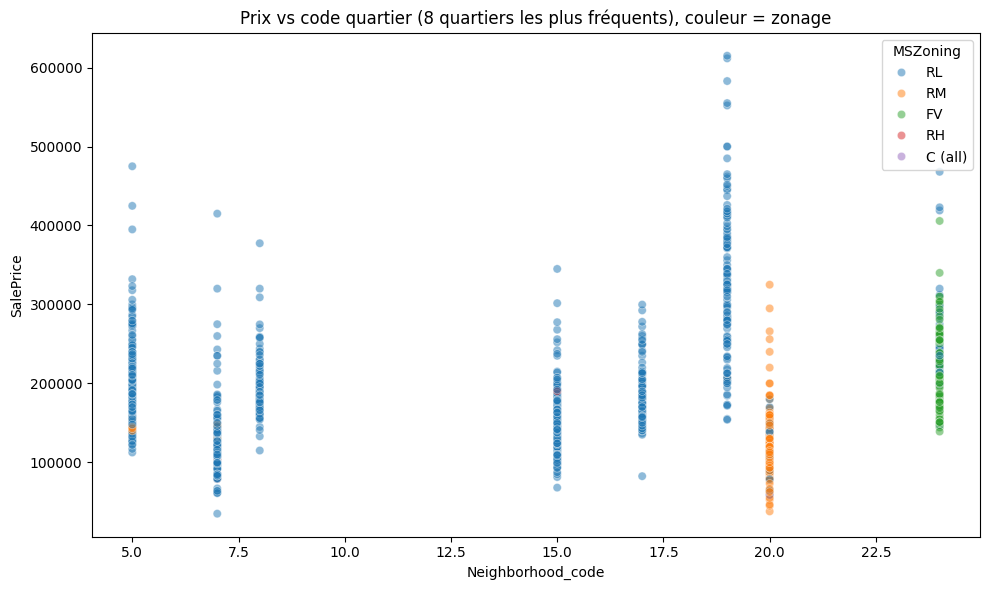

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_loc["Neighborhood_code"] = le.fit_transform(df_loc["Neighborhood"])
sample_nbh = df_loc["Neighborhood"].value_counts().head(8).index
sub = df_loc[df_loc["Neighborhood"].isin(sample_nbh)]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=sub,
    x="Neighborhood_code",
    y="SalePrice",
    hue="MSZoning",
    alpha=0.5,
)
plt.title("Prix vs code quartier (8 quartiers les plus fréquents), couleur = zonage")
plt.tight_layout()
plt.show()


## Section 4: Multicolinéarité (VIF) sur un sous-ensemble d’indicatrices

**À faire :** calculer le VIF sur les **k premières colonnes** dummy + constante (ex. `statsmodels`), ou sur un groupe réduit pour éviter matrices singulières. Interpréter : fortes dépendances entre indicatrices du même bloc (normal).


In [10]:
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    import statsmodels.api as sm

    k = min(25, X_dum.shape[1])
    X_vif = sm.add_constant(X_dum.iloc[:, :k])
    vifs = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
    vif_df = pd.DataFrame({"feature": X_vif.columns, "VIF": vifs})
    print(vif_df.sort_values("VIF", ascending=False).head(15))
except ImportError:
    print("Installez statsmodels : pip install statsmodels")


                 feature        VIF
0                  const  21.330097
16    Neighborhood_NAmes   3.534259
6   Neighborhood_CollgCr   2.763146
21  Neighborhood_OldTown   2.537772
25  Neighborhood_Somerst   2.280674
8   Neighborhood_Edwards   2.280674
20  Neighborhood_NridgHt   2.168694
9   Neighborhood_Gilbert   2.103928
18   Neighborhood_NWAmes   1.922905
23   Neighborhood_Sawyer   1.872792
24  Neighborhood_SawyerW   1.788564
15  Neighborhood_Mitchel   1.788564
7   Neighborhood_Crawfor   1.677747
4   Neighborhood_BrkSide   1.643349
12   Neighborhood_IDOTRR   1.626096


## Section 5: Corrélation partielle (proxy)

**À faire :** avec `pingouin` si disponible, corrélation partielle entre `SalePrice` et une variable encodée en numérique simple, en contrôlant une autre (ex. effet `MSZoning` numérisé). Sinon, expliquer la limite des indicatrices multiples.


In [11]:
try:
    import pingouin as pg

    df_loc["MSZ_num"] = LabelEncoder().fit_transform(df_loc["MSZoning"])
    df_loc["Cond1_num"] = LabelEncoder().fit_transform(df_loc["Condition1"])
    # corrélation partielle : prix vs cond1 en contrôlant MSZoning
    pc = pg.partial_corr(
        data=df_loc,
        x="SalePrice",
        y="Cond1_num",
        covar="MSZ_num",
        method="spearman",
    )
    print(pc)
except ImportError:
    print("pip install pingouin pour la corrélation partielle")


             n         r          CI95         p_val
spearman  2197  0.176069  [0.14, 0.22]  9.477779e-17


In [12]:
import pingouin as pg

pg.corr(
    x=df_loc["SalePrice"],
    y=df_loc["Cond1_num"],
    method="spearman"
)

,n,r,CI95,p_val,power
spearman,2197,0.183659,"[0.14, 0.22]",4.046109e-18,1.0


## Section 7 (optionnelbis) : Synthèse

Résumez : quelles modalités de localisation sont les plus associées à des prix élevés ou bas d’après les corrélations et les graphiques ?
